In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import scipy.stats as stats
from scipy import stats

In [34]:
data=pd.read_csv("marketing_data.csv")

In [35]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country
0,1826,1970,Graduation,Divorced,"$84,835.00",0,0,6/16/14,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,Single,"$57,091.00",0,0,6/15/14,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,Married,"$67,267.00",0,1,5/13/14,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,Together,"$32,474.00",1,1,5/11/14,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,Single,"$21,474.00",1,0,4/8/14,0,6,...,2,7,1,0,0,0,0,1,0,SP


In [36]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   2240 non-null   int64 
 1   Year_Birth           2240 non-null   int64 
 2   Education            2240 non-null   object
 3   Marital_Status       2240 non-null   object
 4    Income              2216 non-null   object
 5   Kidhome              2240 non-null   int64 
 6   Teenhome             2240 non-null   int64 
 7   Dt_Customer          2240 non-null   object
 8   Recency              2240 non-null   int64 
 9   MntWines             2240 non-null   int64 
 10  MntFruits            2240 non-null   int64 
 11  MntMeatProducts      2240 non-null   int64 
 12  MntFishProducts      2240 non-null   int64 
 13  MntSweetProducts     2240 non-null   int64 
 14  MntGoldProds         2240 non-null   int64 
 15  NumDealsPurchases    2240 non-null   int64 
 16  NumWeb

In [37]:
data.columns = data.columns.str.replace(' ', '').str.lower()

In [38]:
data.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'response', 'complain', 'country'],
      dtype='object')

In [39]:
#Once data is imported, investigate variables like Dt_Customer and Income etc and check if they are imported in the right way.
data['income']= data['income'].str.replace('$','').str.replace(',','').astype('float')

In [40]:
data.income

0       84835.0
1       57091.0
2       67267.0
3       32474.0
4       21474.0
         ...   
2235    66476.0
2236    31056.0
2237    46310.0
2238    65819.0
2239    94871.0
Name: income, Length: 2240, dtype: float64

In [41]:
data.dt_customer = pd.to_datetime(data.dt_customer)

C:\Users\hp\AppData\Local\Temp\ipykernel_32920\2431619090.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data.dt_customer = pd.to_datetime(data.dt_customer)


In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2240 non-null   int64         
 1   year_birth           2240 non-null   int64         
 2   education            2240 non-null   object        
 3   marital_status       2240 non-null   object        
 4   income               2216 non-null   float64       
 5   kidhome              2240 non-null   int64         
 6   teenhome             2240 non-null   int64         
 7   dt_customer          2240 non-null   datetime64[ns]
 8   recency              2240 non-null   int64         
 9   mntwines             2240 non-null   int64         
 10  mntfruits            2240 non-null   int64         
 11  mntmeatproducts      2240 non-null   int64         
 12  mntfishproducts      2240 non-null   int64         
 13  mntsweetproducts     2240 non-nul

In [ ]:
# Income values for a few customers are missing. Perform missing value imputation. Assume that the customers with similar education and marital status make the same yearly income, on average.
#You may have to clean the data before performing this. For data cleaning, look into the categories of education and marital-status.

In [43]:
data.isnull().sum()


id                      0
year_birth              0
education               0
marital_status          0
income                 24
kidhome                 0
teenhome                0
dt_customer             0
recency                 0
mntwines                0
mntfruits               0
mntmeatproducts         0
mntfishproducts         0
mntsweetproducts        0
mntgoldprods            0
numdealspurchases       0
numwebpurchases         0
numcatalogpurchases     0
numstorepurchases       0
numwebvisitsmonth       0
acceptedcmp3            0
acceptedcmp4            0
acceptedcmp5            0
acceptedcmp1            0
acceptedcmp2            0
response                0
complain                0
country                 0
dtype: int64

In [44]:
#Check categories in Marital status and education
data.marital_status.unique()

array(['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO',
       'Alone', 'Absurd'], dtype=object)

In [45]:
#Multiple Classes in marital status might have similar interpretation such as :
#Divorced Single Widow AloneAbsurd and YOLO have same meaning as Alone
#Together and Married mean Couple

def change(x):
  if x in['Married','Together']:
     return 'couple'
  else:
     return 'alone'
data.marital_status=data.marital_status.apply(change)



In [46]:
data

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,numstorepurchases,numwebvisitsmonth,acceptedcmp3,acceptedcmp4,acceptedcmp5,acceptedcmp1,acceptedcmp2,response,complain,country
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,6,1,0,0,0,0,0,1,0,SP
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,7,5,0,0,0,0,1,1,0,CA
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,5,2,0,0,0,0,0,0,0,US
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,2,7,0,0,0,0,0,0,0,AUS
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,2,7,1,0,0,0,0,1,0,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,alone,66476.0,0,1,2013-03-07,99,372,...,11,4,0,0,0,0,0,0,0,US
2236,5263,1977,2n Cycle,couple,31056.0,1,0,2013-01-22,99,5,...,3,8,0,0,0,0,0,0,0,SP
2237,22,1976,Graduation,alone,46310.0,1,0,2012-12-03,99,185,...,5,8,0,0,0,0,0,0,0,SP
2238,528,1978,Graduation,couple,65819.0,0,0,2012-11-29,99,267,...,10,3,0,0,0,0,0,0,0,IND


In [47]:
#Imputation of missing values in income column
data['income']=data.groupby(['education','marital_status'])['income'].transform(lambda x: x.fillna(x.mean()))


In [48]:
data.isnull().sum()

id                     0
year_birth             0
education              0
marital_status         0
income                 0
kidhome                0
teenhome               0
dt_customer            0
recency                0
mntwines               0
mntfruits              0
mntmeatproducts        0
mntfishproducts        0
mntsweetproducts       0
mntgoldprods           0
numdealspurchases      0
numwebpurchases        0
numcatalogpurchases    0
numstorepurchases      0
numwebvisitsmonth      0
acceptedcmp3           0
acceptedcmp4           0
acceptedcmp5           0
acceptedcmp1           0
acceptedcmp2           0
response               0
complain               0
country                0
dtype: int64

In [49]:
#Create variables to populate total number of children, age, total spend. From the number of purchases through the 3 channels, we can derive total purchases.
data['age']= 2026-data.year_birth

#axis=1, calculates row-wise sum
data['spending'] = data.loc[:,data.columns.str.startswith('mnt')].sum(axis = 1)
data['children_count']= data.loc[:,['kidhome','teenhome']].sum(axis=1)
data['has_children']=np.where(data.children_count>=1,1,0)
data['total_purchases']= data.loc[:,data.columns.str.endswith('purchases')].sum(axis=1)
data['education_years'] = data.education.replace({'Basic':5,'2n Cycle':8,'Graduation':12,'Master':18,'PhD':21})

C:\Users\hp\AppData\Local\Temp\ipykernel_32920\3215269421.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['education_years'] = data.education.replace({'Basic':5,'2n Cycle':8,'Graduation':12,'Master':18,'PhD':21})


In [50]:
data.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'response', 'complain', 'country', 'age', 'spending',
       'children_count', 'has_children', 'total_purchases', 'education_years'],
      dtype='object')

In [51]:
data

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,acceptedcmp2,response,complain,country,age,spending,children_count,has_children,total_purchases,education_years
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,1,0,SP,56,1190,0,0,15,12
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,1,1,0,CA,65,577,0,0,18,12
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,0,US,68,251,1,1,11,12
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,0,0,0,AUS,59,11,2,1,4,12
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,1,0,SP,37,91,1,1,8,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,alone,66476.0,0,1,2013-03-07,99,372,...,0,0,0,US,50,689,1,1,20,21
2236,5263,1977,2n Cycle,couple,31056.0,1,0,2013-01-22,99,5,...,0,0,0,SP,49,55,1,1,5,8
2237,22,1976,Graduation,alone,46310.0,1,0,2012-12-03,99,185,...,0,0,0,SP,50,309,1,1,14,12
2238,528,1978,Graduation,couple,65819.0,0,0,2012-11-29,99,267,...,0,0,0,IND,48,1383,0,0,20,12


In [23]:
#Create box-plots and histograms to understand the distributions and outliers. Perform outlier treatment.
data.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'response', 'complain', 'country'],
      dtype='object')

In [52]:
num_vars=['income', 'spending', 'age', 'total_purchases']

In [53]:
num_vars

['income', 'spending', 'age', 'total_purchases']

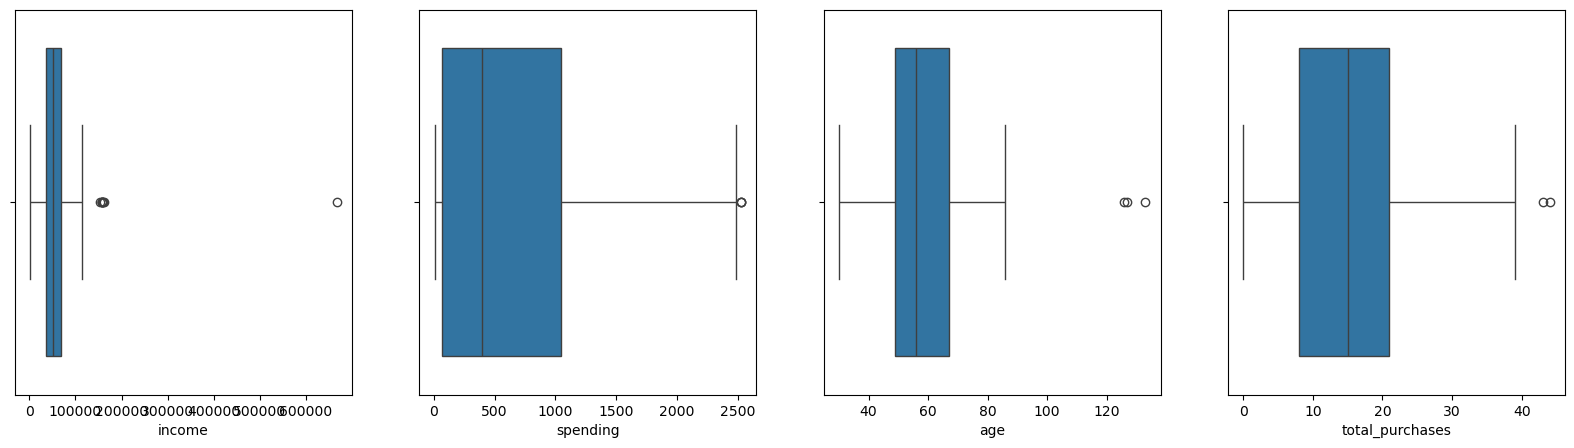

In [54]:
f,ax= plt.subplots(1,len(num_vars),figsize=(20,5))
i=0
for v in num_vars:
    sns.boxplot(x= data[v],ax=ax[i] )
    i+=1
plt.show()

In [55]:
%matplotlib inline 

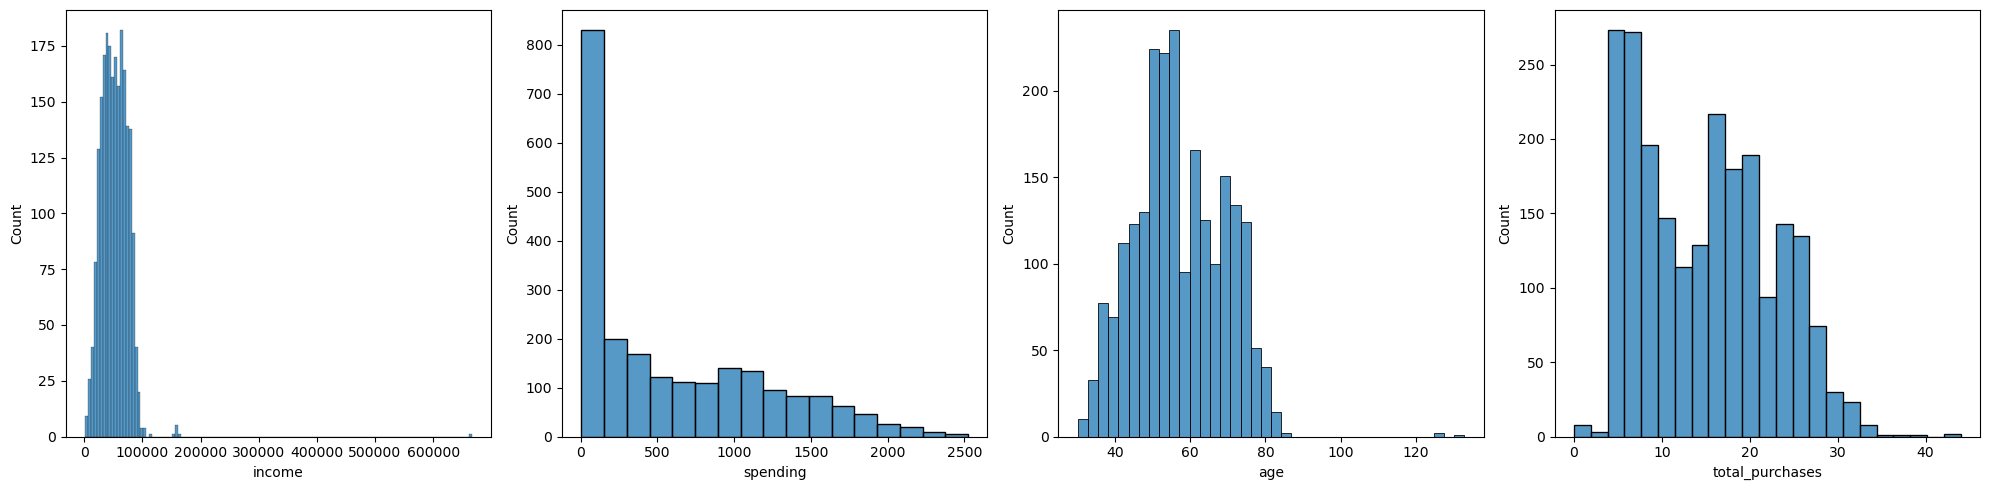

In [56]:
f,ax= plt.subplots(1,len(num_vars),figsize=(20,5))
i=0
for v in num_vars:
    sns.histplot(x= data[v],ax=ax[i])
    i+=1
plt.tight_layout()   
plt.show()

In [138]:
#Spending is highly right skewed
#Income has extreme outliers

In [57]:
#outlier Capping
def outlier_treatment(dataframe,column):
    Q1= dataframe[column].quantile(0.25)
    Q3=dataframe[column].quantile(0.75)
    IQR= Q3-Q1
    lower_bound= Q1-1.5 * IQR
    upper_bound= Q3+ 1.5 * IQR
    dataframe[column]= np.where(dataframe[column]>upper_bound,upper_bound,np.where(dataframe[column]<lower_bound,lower_bound, dataframe[column]))
    return dataframe

data = outlier_treatment(data, 'income')
data = outlier_treatment(data, 'age')
data = outlier_treatment(data, 'spending')
data = outlier_treatment(data, 'total_purchases')

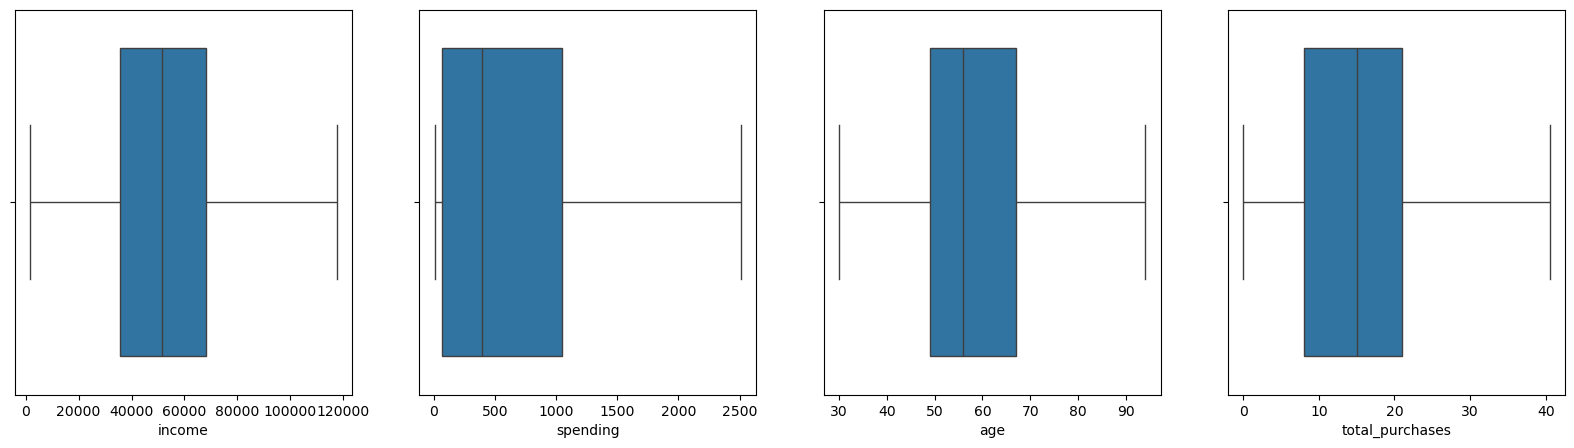

In [58]:
f,ax= plt.subplots(1,len(num_vars),figsize=(20,5))
i=0
for v in num_vars:
    sns.boxplot(x= data[v],ax=ax[i] )
    i+=1
plt.show()

In [59]:
#Use ordinal encoding and one hot encoding according to different types of categorical variables.
data.select_dtypes('object')

,education,marital_status,country
0,Graduation,alone,SP
1,Graduation,alone,CA
2,Graduation,couple,US
3,Graduation,couple,AUS
4,Graduation,alone,SP
...,...,...,...
2235,PhD,alone,US
2236,2n Cycle,couple,SP
2237,Graduation,alone,SP
2238,Graduation,couple,IND


In [27]:
#For eductaion we use ordinal encoder
data.education.unique()

array(['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic'], dtype=object)

In [62]:
edu_dict= {"Basic":0,"2n Cycle":1,"Graduation":2,"Master":3,"PhD":4}

In [63]:
edu_dict

{'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}

In [66]:
data["education_encoded"]= data["education"].map(edu_dict)

In [67]:
data

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,response,complain,country,age,spending,children_count,has_children,total_purchases,education_years,education_encoded
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,1,0,SP,56.0,1190.0,0,0,15.0,12,2
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,1,0,CA,65.0,577.0,0,0,18.0,12,2
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,0,0,US,68.0,251.0,1,1,11.0,12,2
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,0,0,AUS,59.0,11.0,2,1,4.0,12,2
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,1,0,SP,37.0,91.0,1,1,8.0,12,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,alone,66476.0,0,1,2013-03-07,99,372,...,0,0,US,50.0,689.0,1,1,20.0,21,4
2236,5263,1977,2n Cycle,couple,31056.0,1,0,2013-01-22,99,5,...,0,0,SP,49.0,55.0,1,1,5.0,8,1
2237,22,1976,Graduation,alone,46310.0,1,0,2012-12-03,99,185,...,0,0,SP,50.0,309.0,1,1,14.0,12,2
2238,528,1978,Graduation,couple,65819.0,0,0,2012-11-29,99,267,...,0,0,IND,48.0,1383.0,0,0,20.0,12,2


In [77]:
#For country and marital status use one hot encoding
marital_encoded=pd.get_dummies(data['marital_status'],columns=['marital_status'],dtype=int)
marital_encoded


,alone,couple
0,1,0
1,1,0
2,0,1
3,0,1
4,1,0
...,...,...
2235,1,0
2236,0,1
2237,1,0
2238,0,1


In [78]:

data= pd.concat([data,marital_encoded],axis=1)

In [80]:
data

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,country,age,spending,children_count,has_children,total_purchases,education_years,education_encoded,alone,couple
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,SP,56.0,1190.0,0,0,15.0,12,2,1,0
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,CA,65.0,577.0,0,0,18.0,12,2,1,0
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,US,68.0,251.0,1,1,11.0,12,2,0,1
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,AUS,59.0,11.0,2,1,4.0,12,2,0,1
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,SP,37.0,91.0,1,1,8.0,12,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,alone,66476.0,0,1,2013-03-07,99,372,...,US,50.0,689.0,1,1,20.0,21,4,1,0
2236,5263,1977,2n Cycle,couple,31056.0,1,0,2013-01-22,99,5,...,SP,49.0,55.0,1,1,5.0,8,1,0,1
2237,22,1976,Graduation,alone,46310.0,1,0,2012-12-03,99,185,...,SP,50.0,309.0,1,1,14.0,12,2,1,0
2238,528,1978,Graduation,couple,65819.0,0,0,2012-11-29,99,267,...,IND,48.0,1383.0,0,0,20.0,12,2,0,1


In [121]:
country_encoded=pd.get_dummies(data['country'],columns=['country'],dtype=int)
country_encoded

,AUS,CA,GER,IND,ME,SA,SP,US
0,0,0,0,0,0,0,1,0
1,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,1
3,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...
2235,0,0,0,0,0,0,0,1
2236,0,0,0,0,0,0,1,0
2237,0,0,0,0,0,0,1,0
2238,0,0,0,1,0,0,0,0


In [122]:
data= pd.concat([data,country_encoded],axis=1)

In [81]:
data = data.drop(columns=["education_years"])

In [134]:
#Create a heatmap to showcase correlation between different pairs of variables.

data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 44 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   2240 non-null   int64         
 1   year_birth           2240 non-null   int64         
 2   education            2240 non-null   object        
 3   marital_status       2240 non-null   object        
 4   income               2240 non-null   float64       
 5   kidhome              2240 non-null   int64         
 6   teenhome             2240 non-null   int64         
 7   dt_customer          2240 non-null   datetime64[ns]
 8   recency              2240 non-null   int64         
 9   mntwines             2240 non-null   int64         
 10  mntfruits            2240 non-null   int64         
 11  mntmeatproducts      2240 non-null   int64         
 12  mntfishproducts      2240 non-null   int64         
 13  mntsweetproducts     2240 non-nul

In [124]:
var_cor = ['income', 'age', 'children_count', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth','spending', 'total_purchases'
       ]

In [125]:
cor_data = data[var_cor].corr()

In [126]:
data[var_cor]
cor_data

,income,age,children_count,recency,mntwines,mntfruits,mntmeatproducts,mntfishproducts,mntsweetproducts,mntgoldprods,numdealspurchases,numwebpurchases,numcatalogpurchases,numstorepurchases,numwebvisitsmonth,spending,total_purchases
income,1.000000,0.204498,-0.345089,0.005322,0.704978,0.519905,0.682947,0.533212,0.532816,0.397070,-0.114456,0.468545,0.690464,0.649887,-0.648273,0.803614,0.679422
age,0.204498,1.000000,0.093232,0.020039,0.161284,0.016134,0.031155,0.042358,0.018988,0.060248,0.064649,0.150248,0.124070,0.134416,-0.120136,0.113313,0.175382
children_count,-0.345089,0.093232,1.000000,0.018053,-0.351909,-0.394853,-0.502208,-0.425503,-0.383137,-0.266095,0.439684,-0.146361,-0.439904,-0.321125,0.418419,-0.498898,-0.245846
recency,0.005322,0.020039,0.018053,1.000000,0.016064,-0.004306,0.023056,0.001079,0.022670,0.016693,-0.001098,-0.010726,0.025110,0.000799,-0.021445,0.020445,0.005981
mntwines,0.704978,0.161284,-0.351909,0.016064,1.000000,0.389637,0.562667,0.399753,0.386581,0.387516,0.010940,0.542265,0.635226,0.642100,-0.320653,0.891845,0.713954
mntfruits,0.519905,0.016134,-0.394853,-0.004306,0.389637,1.000000,0.543105,0.594804,0.567164,0.392995,-0.132114,0.296735,0.487917,0.461758,-0.418383,0.614203,0.456170
mntmeatproducts,0.682947,0.031155,-0.502208,0.023056,0.562667,0.543105,1.000000,0.568402,0.523846,0.350609,-0.122415,0.293761,0.723827,0.479659,-0.539470,0.842949,0.552596
mntfishproducts,0.533212,0.042358,-0.425503,0.001079,0.399753,0.594804,0.568402,1.000000,0.579870,0.422875,-0.139361,0.293681,0.534478,0.459855,-0.446003,0.642849,0.470209
mntsweetproducts,0.532816,0.018988,-0.383137,0.022670,0.386581,0.567164,0.523846,0.579870,1.000000,0.369724,-0.120100,0.348544,0.490924,0.448756,-0.423294,0.602987,0.473672
mntgoldprods,0.397070,0.060248,-0.266095,0.016693,0.387516,0.392995,0.350609,0.422875,0.369724,1.000000,0.049085,0.421836,0.437697,0.381678,-0.250719,0.524295,0.494202


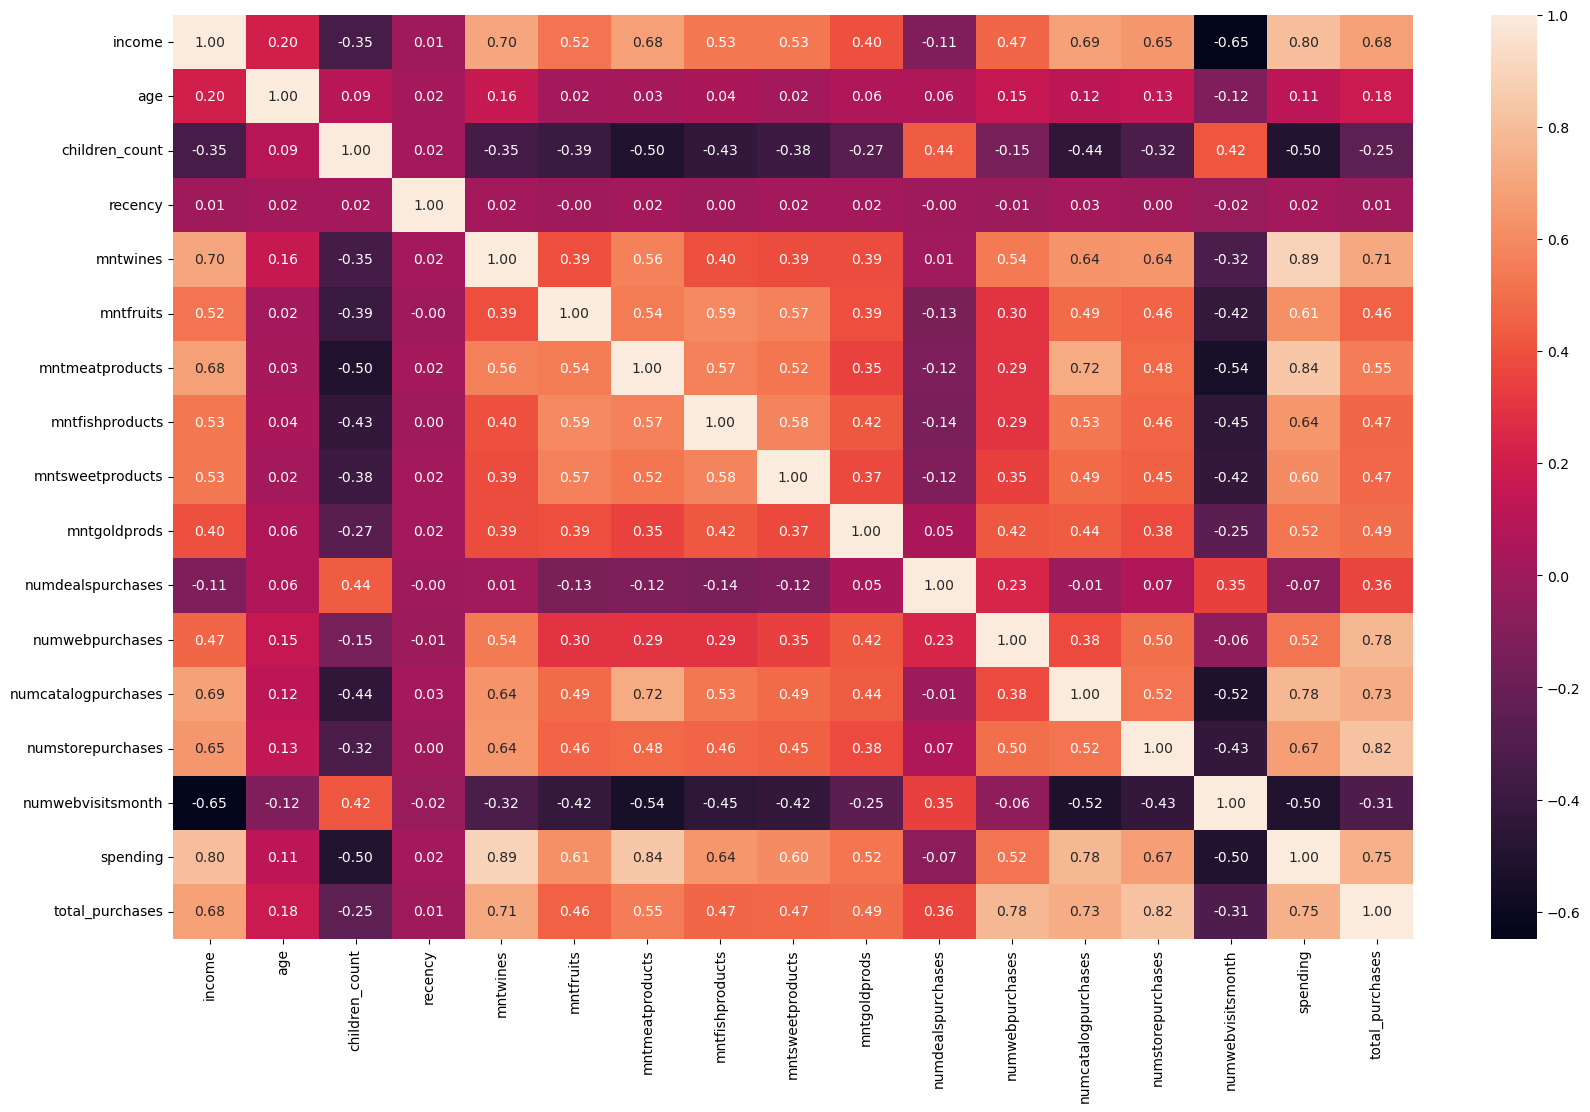

In [127]:

plt.figure(figsize=(20,12))
sns.heatmap(cor_data, annot=True,fmt='.2f')
plt.show()

In [135]:
#Hypothesis Testing
#1.Older people are not as tech savvy and probably prefer shopping in store
#H0: for old customers[no of purchases store<=no of purchases online]
#H1: for old customers[no of purchases store]>no of purchases online]
import numpy as np
from scipy import stats

In [136]:
store= data.loc[data.age>=60,'numstorepurchases']
online= data.loc[data.age>=60,'numwebpurchases']
stat,pvalue= stats.ttest_ind(store,online,alternative='greater')

In [51]:
store

1       7
2       5
5       5
6       7
8       9
       ..
2217    7
2224    3
2225    3
2227    5
2233    2
Name: numstorepurchases, Length: 910, dtype: int64

In [52]:
online

1        7
2        3
5        4
6       10
8        6
        ..
2217     4
2224     2
2225     2
2227     5
2233     2
Name: numwebpurchases, Length: 910, dtype: int64

In [137]:

stat
pvalue

1.6358824528627323e-36

In [106]:
# pvalue<=0.05:
#    print("We reject H0")
#else:
#    print("Fail to reject H0")

In [ ]:
#Since p is very low(0.05), we reject H0.
#Older customers prefer store purchases.

In [ ]:
#2. Customers with kids probably have less time to visit a store and would prefer to shop online
#Ho:for customers with children(numwebpurchases)<=numstorepurchases
#H1:for customers with children(numwebpurchases)>numstorepurchases

In [145]:

import numpy as np

import scipy.stats as stats

store = data.loc[data['has_children']==1,'numstorepurchases']
web = data.loc[data['has_children']==1,'numwebpurchases']
stats, pvalue=stats.ttest_ind(store,web, alternative="greater" )

In [146]:
pvalue
#Reject H0, as p is very low.
#Conclusion: Customers with kids prefer to purchase online as compared to store.



4.6156632446103927e-32

In [ ]:
#3. Other distribution channels may cannibalize sales at the store

In [ ]:
#H0 : purchases from other channels <= no. of store purchases
#Ha : purchases from other channels > no. of store purchases

In [144]:
import numpy as np
from scipy import stats
other = data.loc[:,['numwebpurchases', 'numcatalogpurchases']].sum(axis = 1)
store = data.loc[:, 'numstorepurchases']
stats.ttest_ind(other, store, alternative ="greater")

TtestResult(statistic=7.884334964023309, pvalue=1.971324447658957e-15, df=4478.0)

In [ ]:
#Reject H0:as p-value is very low
#Conclusion: Other distribution channels are preferred over store purchases


In [183]:
#4. Identify whether the US fares significantly better than the rest of the world in terms of total purchases
#H0:Total_purchases_US<=Total_purchases_row
#H1:Total_purchases_US>Total_purchases_row
import scipy.stats as stats # Correct import
import numpy as np
US= data.loc[data.country=="US","total_purchases"].astype("int")

Row= data.loc[data.country !="US","total_purchases"].astype("int")
stats.ttest_ind(US,Row, alternative ="greater")

TtestResult(statistic=1.7220814441458574, pvalue=0.042596467731474096, df=2238.0)

In [ ]:
# Since p is less than 0.05, reject H0
#Total purchases from US >Rest of the world.

In [193]:
# 1. Comparative Product Performance

prod_data = data.loc[:, data.columns.str.startswith("mnt")].mean().round(2).sort_values(ascending=False)



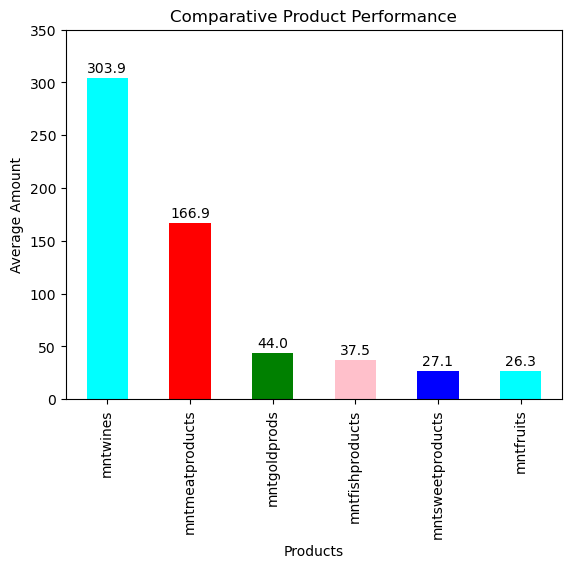

In [202]:
ax=prod_data.plot(title="Comparative Product Performance",kind="bar",color=["cyan","red","green","pink","blue"])
plt.xlabel('Products')

plt.ylabel('Average Amount')
plt.ylim(0, 350)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 7), 
                textcoords='offset points')

plt.show()
plt.show()

In [ ]:
#Amount spent on wine is the highest and fruits lowest.

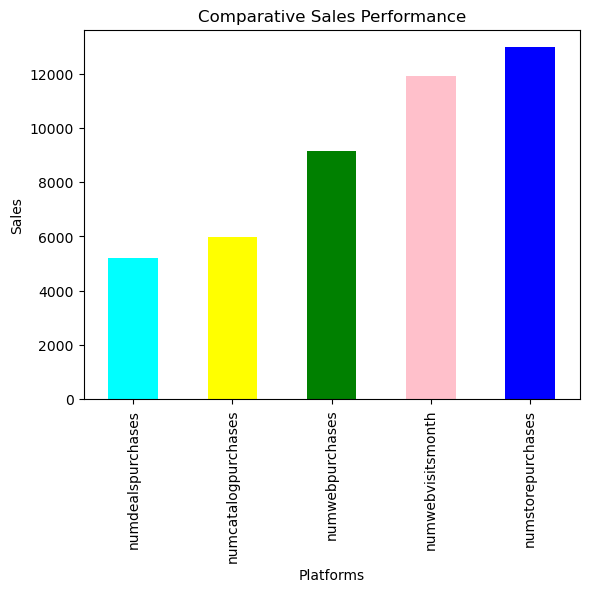

In [220]:
#2. Sales by different platforms
sales_data = data.loc[:, data.columns.str.startswith("num")].sum().round(2).sort_values(ascending=True)
sales_data.plot(title="Comparative Sales Performance",kind="bar",color=["cyan","yellow","green","pink","blue"])
plt.xlabel('Platforms')

plt.ylabel('Sales')



plt.show()
plt.show()

In [204]:
#Stores generate the maximum sales.

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'response', 'complain', 'country', 'age', 'spending',
       'children_count', 'has_children', 'total_purchases',
       'education_encoded', 'alone', 'couple', 'AUS', 'CA', 'GER', 'IND', 'ME',
       'SA', 'SP', 'US'],
      dtype='object')

In [209]:
sales_data

numstorepurchases      12970
numwebvisitsmonth      11909
numwebpurchases         9150
numcatalogpurchases     5963
numdealspurchases       5208
dtype: int64

In [236]:
# 3. Explore the relationship between age and campaign acceptance rate (acceptedcmp5) using a bar plot
data['age_grp'] = pd.cut(data.age, bins = 5, labels = [1,2,3,4,5])
grpd_age = data.groupby('age_grp')['age'].agg(['min','max'])
grpd_age['group'] = grpd_age['min'].astype(str) + ' - ' +grpd_age['max'].astype(str)

C:\Users\hp\AppData\Local\Temp\ipykernel_32920\3665786160.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grpd_age = data.groupby('age_grp')['age'].agg(['min','max'])


In [237]:
grpd_age


,min,max,group
age_grp,,,
1,30.0,42.0,30.0 - 42.0
2,43.0,55.0,43.0 - 55.0
3,56.0,68.0,56.0 - 68.0
4,69.0,81.0,69.0 - 81.0
5,82.0,94.0,82.0 - 94.0


In [239]:
data.age_grp = data.age_grp.replace([1,2,3,4,5], grpd_age.group)

C:\Users\hp\AppData\Local\Temp\ipykernel_32920\1402206506.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  data.age_grp = data.age_grp.replace([1,2,3,4,5], grpd_age.group)


In [241]:
data

,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mntwines,...,couple,AUS,CA,GER,IND,ME,SA,SP,US,age_grp
0,1826,1970,Graduation,alone,84835.0,0,0,2014-06-16,0,189,...,0,0,0,0,0,0,0,1,0,56.0 - 68.0
1,1,1961,Graduation,alone,57091.0,0,0,2014-06-15,0,464,...,0,0,1,0,0,0,0,0,0,56.0 - 68.0
2,10476,1958,Graduation,couple,67267.0,0,1,2014-05-13,0,134,...,1,0,0,0,0,0,0,0,1,56.0 - 68.0
3,1386,1967,Graduation,couple,32474.0,1,1,2014-05-11,0,10,...,1,1,0,0,0,0,0,0,0,56.0 - 68.0
4,5371,1989,Graduation,alone,21474.0,1,0,2014-04-08,0,6,...,0,0,0,0,0,0,0,1,0,30.0 - 42.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10142,1976,PhD,alone,66476.0,0,1,2013-03-07,99,372,...,0,0,0,0,0,0,0,0,1,43.0 - 55.0
2236,5263,1977,2n Cycle,couple,31056.0,1,0,2013-01-22,99,5,...,1,0,0,0,0,0,0,1,0,43.0 - 55.0
2237,22,1976,Graduation,alone,46310.0,1,0,2012-12-03,99,185,...,0,0,0,0,0,0,0,1,0,43.0 - 55.0
2238,528,1978,Graduation,couple,65819.0,0,0,2012-11-29,99,267,...,1,0,0,0,1,0,0,0,0,43.0 - 55.0


In [264]:
ac_5= data[data.acceptedcmp5==1].age_grp.value_counts().sort_index()

In [265]:
ac_5

age_grp
30.0 - 42.0    29
43.0 - 55.0    53
56.0 - 68.0    39
69.0 - 81.0    37
82.0 - 94.0     5
Name: count, dtype: int64

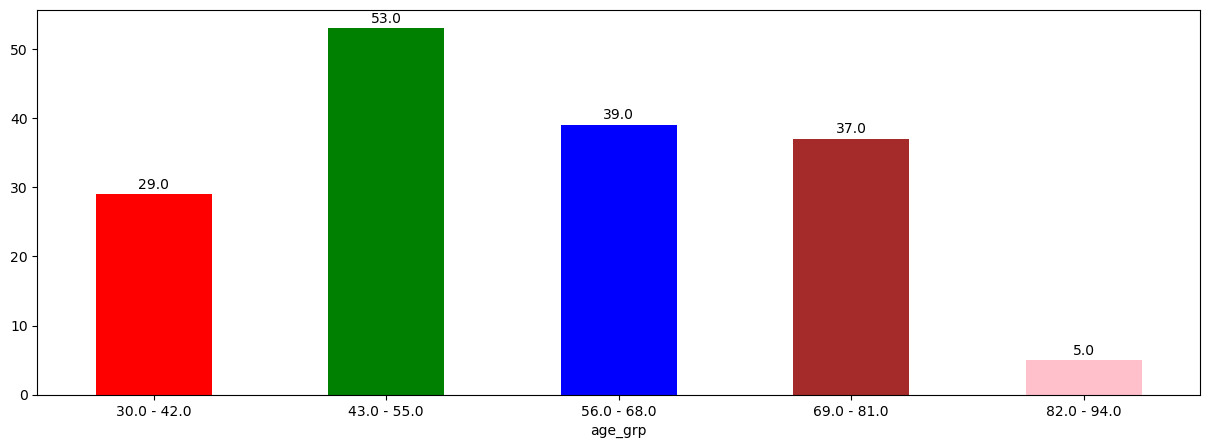

In [269]:
plt.figure(figsize = (15,5))
ax=ac_5.plot.bar(color = ['red', 'green', 'blue', 'brown', 'pink'])
plt.xticks(rotation = 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 7), 
                textcoords='offset points')
plt.show()

In [ ]:
#The age group 41-53 accepted the last campaign. However the age group 80-92 accepted the least.

In [266]:
#4. Country Vs Last_Campaign Performance
country_last= data.loc[data.acceptedcmp5==1,"country"].value_counts()

In [267]:
country_last

country
SP     89
CA     21
SA     21
AUS    13
GER     8
IND     6
US      5
Name: count, dtype: int64

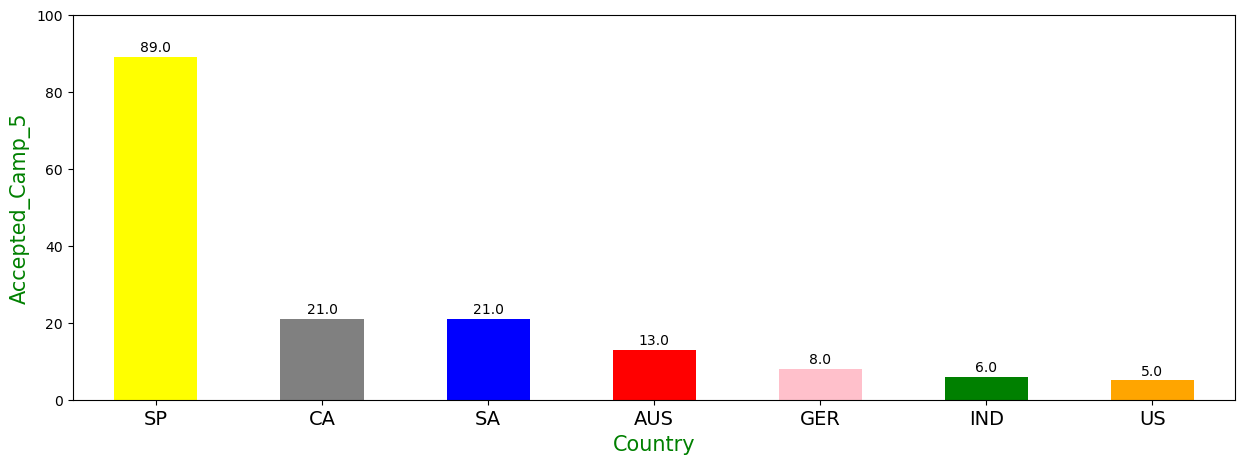

In [285]:
plt.figure(figsize = (15,5))
ax=country_last.plot(kind= 'bar',color = ['yellow', 'grey', 'blue', 'red', 'pink','green','orange'])
plt.xticks(rotation = 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 7), 
                textcoords='offset points')
plt.xlabel( 'Country', size = 15, color = 'green')
plt.ylabel( 'Accepted_Camp_5', size = 15, color = 'green')
plt.ylim(0,100)
plt.xticks(size = 14)
plt.show()

In [ ]:
#5. No of children_count Vs spending

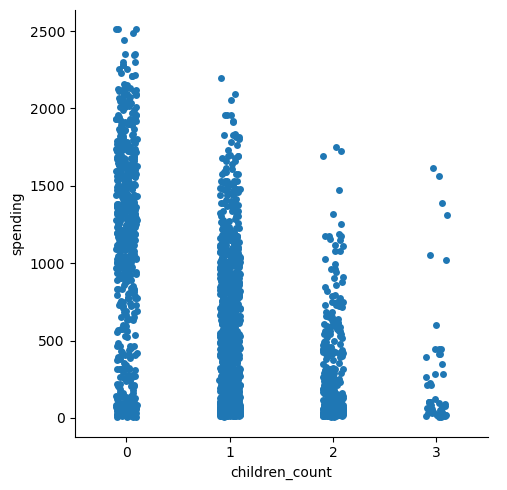

In [293]:
sns.catplot(x = 'children_count', y = 'spending',data = data, kind = "strip")
plt.show()

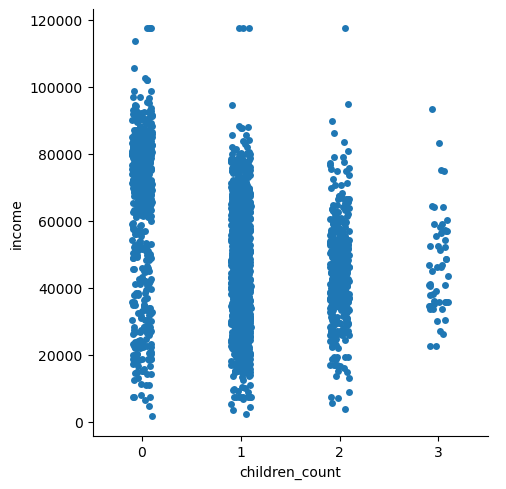

In [307]:
sns.catplot(x = 'children_count', y = 'income',data = data, kind = "strip")
plt.show()

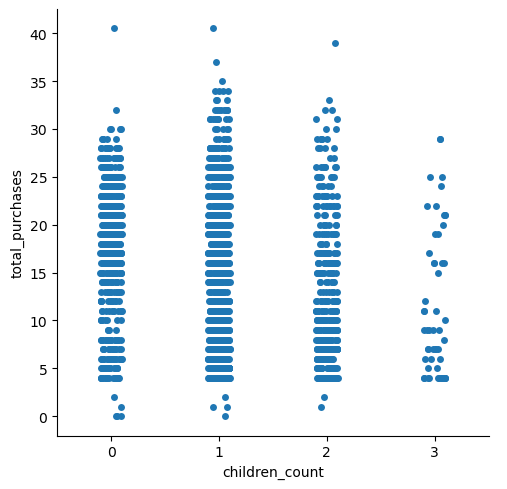

In [308]:
sns.catplot(x = 'children_count', y = 'total_purchases',data = data, kind = "strip")
plt.show()

In [300]:
#Education Vs Customer Complaints
complain = data.loc[data.complain==1,"education"].value_counts()
complain

education
Graduation    14
2n Cycle       4
Master         2
PhD            1
Name: count, dtype: int64

In [297]:
data.columns

Index(['id', 'year_birth', 'education', 'marital_status', 'income', 'kidhome',
       'teenhome', 'dt_customer', 'recency', 'mntwines', 'mntfruits',
       'mntmeatproducts', 'mntfishproducts', 'mntsweetproducts',
       'mntgoldprods', 'numdealspurchases', 'numwebpurchases',
       'numcatalogpurchases', 'numstorepurchases', 'numwebvisitsmonth',
       'acceptedcmp3', 'acceptedcmp4', 'acceptedcmp5', 'acceptedcmp1',
       'acceptedcmp2', 'response', 'complain', 'country', 'age', 'spending',
       'children_count', 'has_children', 'total_purchases',
       'education_encoded', 'alone', 'couple', 'AUS', 'CA', 'GER', 'IND', 'ME',
       'SA', 'SP', 'US', 'age_grp'],
      dtype='object')

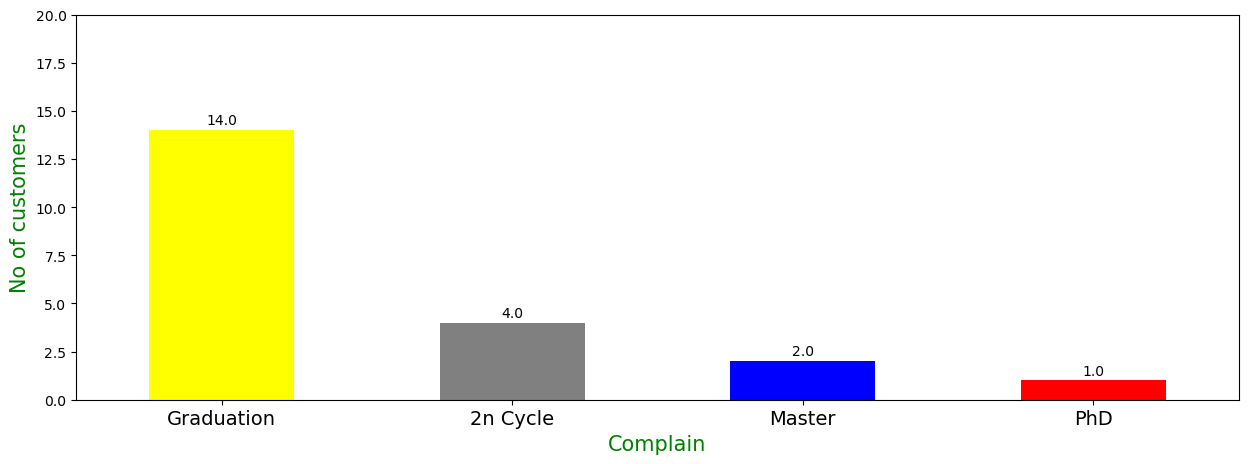

In [303]:
plt.figure(figsize = (15,5))
ax=complain.plot(kind= 'bar',color = ['yellow', 'grey', 'blue', 'red', 'pink','green','orange'])
plt.xticks(rotation = 0)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 7), 
                textcoords='offset points')
plt.xlabel( 'Complain', size = 15, color = 'green')
plt.ylabel( 'No of customers', size = 15, color = 'green')
plt.ylim(0,20)
plt.xticks(size = 14)
plt.show()

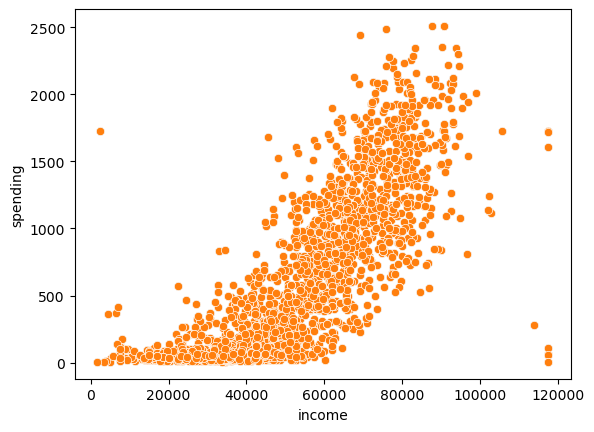

In [305]:
sns.scatterplot(x="income",y="spending",data=data)
plt.show()

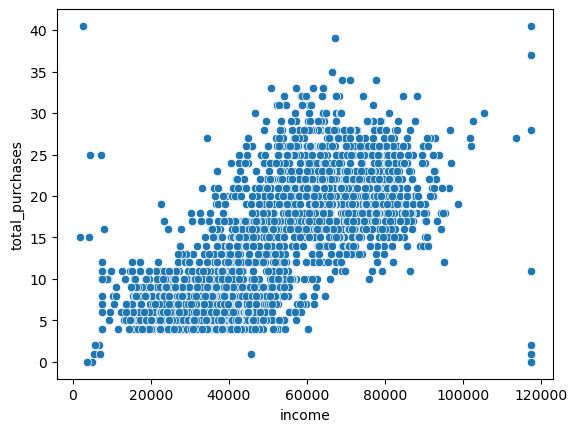

In [306]:
sns.scatterplot(x="income",y="total_purchases",data=data)
plt.show()